# Introduction into Data Science - Assignment Part II

This is the second part of the assignment in IDS 2023/2024.

This part of the assignment consists of five questions — each of these questions is contained in a separate Jupyter notebook:
- [Question 1: Data Preprocessing](Q1_Preprocessing_Visualization.ipynb)
- [Question 2: Association Rules](Q2_Frequent_Itemsets_Association_Rules.ipynb)
- [Question 3: Process Mining](Q3_Process_Mining.ipynb)
- [Question 4: Text Mining](Q4_Text_Mining.ipynb)
- [Question 5: Big Data](Q5_Big_Data.ipynb)

Additional required files are in two folders.
- [datasets](datasets/)
- [scripts](scripts/)

Please use the provided notebook to work on the questions. When you are done, upload your version of each of the notebooks to Moodle. Your submission will, therefore, consist of five jupyter notebook and _no_ additional file. Any additionally provided files will not be considered in grading.
Enter your commented Python code and answers in the corresponding cells. Make sure to answer all questions in a clear and explicit manner and discuss your outputs. _Please do not change the general structure of this notebook_. You can, however, add additional markdown or code cells if necessary. Please **DO NOT CLEAR THE OUTPUT** of the notebook you are submitting! Additionally, please ensure that the code in the notebook runs if placed in the same folder as all of the provided files, delivering the same outputs as the ones you submit in the notebook. This includes being runnable in the bundled conda environment.

*Please make sure to include the names and matriculation numbers of all group members in the provided slots in each of the notebooks.* If a name or a student id is missing, the student will not receive any points.

Hint 1: **Plan your time wisely.** A few parts of this assignment may take some time to run. It might be necessary to consider time management when you plan your group work. Also, do not attempt to upload your assignment at the last minute before the deadline. This often does not work, and you will miss the deadline. Late submissions will not be considered.

Hint 2: RWTHMoodle allows multiple submissions, with every new submission overwriting the previous one. **Partial submissions are possible and encouraged.** This might be helpful in case of technical issues with RWTHMoodle, which may occur close to the deadline.

Hint 3: As a technical note. Some IDEs such as DataSpell may automatically strip jupyter notebook cell metadata. If you are able, please re-add it from the source notebooks before submission. This is necessary for our grading.

Enter your group number and members with matriculation numbers below.

In [1]:
GROUP_NO = 47 # group number
GROUP_MEMBERS = {
    460101: "Feiyu Wang", # mat. no. : name,
    460790: "Malte Schörken",
    461277: "Chenmingxuan Feng",
}

---

In [2]:
# required imports
# please do not edit!
import pandas as pd
import pm4py
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Process Mining (23 points)
Your "Introduction into Data Science" course at the PADS chair has made you curious about Process Mining. 
You decide that you want to get a deeper understanding of the learned concepts. To do so, you use PM4Py - the documentation of this library can be found at: [PM4Py documentation](https://pm4py.fit.fraunhofer.de/static/assets/api/2.7.5/api.html)

## Part I: Implementation of Core Concepts (8 points)

You find an event log describing how the individual groups of the second part of the IDS Assignment two years ago approached the tasks, as a CSV file called **event_log_pt1.csv**. 
Your friend points out that this seems like an ideal log to implement the things you learned in lecture on an easy-to-understand log.

#### a)
You begin by loading the event log into a variable called `log_groups`. 
The event log should be imported as a pandas dataframe which is a PM4Py suitable data format and compute the following variables:
* `case_count`: How many groups took Part II of the assignment in Wintersemester 2021/2022?
* `activity_count`: How many unique activities were logged? 



In [3]:
# YOUR CODE HERE
df = pd.read_csv('q3_event_log_pt1.csv', sep=',')

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

log_groups = pm4py.format_dataframe(df, case_id='Group Number', activity_key='Activity', timestamp_key='Timestamp', timest_format="yyyy-mm-dd hh:mm:ss")
display(log_groups.head())
log_groups = pm4py.convert_to_event_log(log_groups)

case_count = len(log_groups)
activity_count = len(df['Activity'].unique())
print(f"The object log contains {case_count} cases and {activity_count} activities. ")

,Group Number,Activity,Timestamp,case:concept:name,concept:name,time:timestamp,@@index,@@case_index
0,1,First download of assignment,2021-12-09 07:30:00+00:00,1,First download of assignment,2021-12-09 07:30:00+00:00,0,0
1,1,Revisit PM Exercise in Moodle,2021-12-09 14:55:00+00:00,1,Revisit PM Exercise in Moodle,2021-12-09 14:55:00+00:00,1,0
2,1,Solve tasks individually,2021-12-09 15:22:00+00:00,1,Solve tasks individually,2021-12-09 15:22:00+00:00,2,0
3,1,Recheck/Compare Task Results,2021-12-09 15:28:00+00:00,1,Recheck/Compare Task Results,2021-12-09 15:28:00+00:00,3,0
4,1,Redo Task(s),2021-12-09 15:34:00+00:00,1,Redo Task(s),2021-12-09 15:34:00+00:00,4,0


The object log contains 516 cases and 8 activities. 


C:\ProgramData\Anaconda3\envs\env-ids-ws23\lib\site-packages\pm4py\utils.py:503: UserWarning: the EventLog class has been deprecated and will be removed in a future release.
  warnings.warn("the EventLog class has been deprecated and will be removed in a future release.")


Given the low number of activities, you decide to plot the directly-follows graph and manually detect the first cut the Inductive Miner would apply.

#### b)
Use PM4Py to create the directly follows graph, using `dfg` as variable name for the graph structure, `start_act` as variable name for the start activities, and `end_act` for the final activities. Show the directly-follows graph.


The start activities are:


{'First download of assignment': 516}

The end activities are:


{'Submit results': 487, 'Coordinate with Assignment Group': 29}

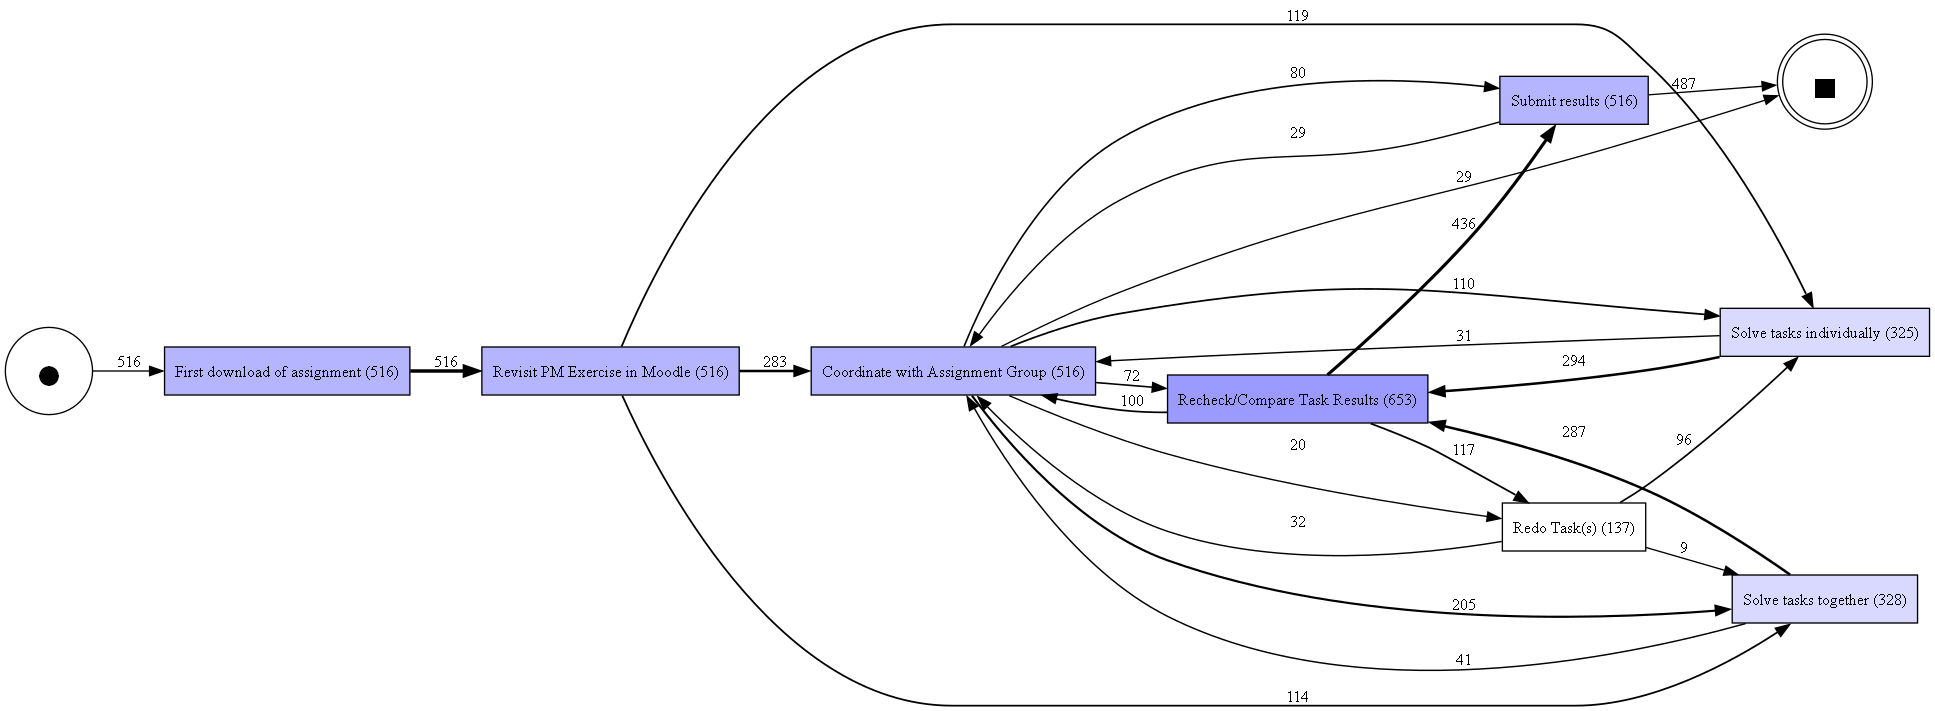

In [4]:
# YOUR CODE HERE

print('The start activities are:')
display(pm4py.get_start_activities(log_groups))
print('The end activities are:')
display(pm4py.get_end_activities(log_groups))

dfg, start_act, end_act = pm4py.discover_directly_follows_graph(log_groups)

pm4py.view_dfg(dfg=dfg, start_activities=start_act, end_activities=end_act)


#### c)
Based on the DFG, name the first type of cut that is identified by the Inductive Miner. Briefly explain why this is the correct cut.

*Hint: You can of course also use other functionalities of PM4Py to identify the cut. Nevertheless, your submitted notebook is expected to contain the DFG.*


__Student Answer:__ 

First cut: Sequence Cut

{{'First download of assignment'}, 
{'Revisit PM Exercise in Moodle'},
{'Coordinate with Assignment Group', 'Solve tasks individually', 'Recheck/Compare Task Results', 'Redo Task(s)', 'Solve tasks together', 'Submit results'}}

The occurrence of the activity 'First download of assignment' consistently precedes that of 'Revisit PM Exercise in Moodle.', both of these activities consistently precede all other activities in the sequence. This characteristic qualifies the identified set of activities as a sequence cut. Since the sequence cut is always the first cut we are looking for the detected sequence cut is the correct decision.

#### d)
Give the activity-partitions as a list and store it into a variable called `first_cut_partitions`. This list should include at least two sets containing only activity names (no start or end).
Note, that the number of partitions depends on the maximum cut you identified.

For example, `[{"c","d"}, {"a","b"}]` indicates two partitions: one with a and b and the other with c and d.

In [5]:
# YOUR CODE HERE
first_cut_partitions = [
    {'First download of assignment'}, 
    {'Revisit PM Exercise in Moodle'},
    {'Coordinate with Assignment Group', 'Solve tasks individually', 'Recheck/Compare Task Results', 'Redo Task(s)', 'Solve tasks together', 'Submit results'}
]
first_cut_partitions

[{'First download of assignment'},
 {'Revisit PM Exercise in Moodle'},
 {'Coordinate with Assignment Group',
  'Recheck/Compare Task Results',
  'Redo Task(s)',
  'Solve tasks individually',
  'Solve tasks together',
  'Submit results'}]

#### e)
Having identified the cut, split the event log accordingly. 
Create five variables, called `sub_log_groups1`, `sub_log_groups2`, `sub_log_groups3`, `sub_log_groups4`, and `sub_log_groups5`. 
Create the sublog for each of your identified partitions and store it in one of the variables. Assign `None` to all variables you don't use.

In [6]:
# YOUR CODE HERE
log_groups = pm4py.format_dataframe(df, case_id='Group Number', activity_key='Activity', timestamp_key='Timestamp', timest_format="yyyy-mm-dd hh:mm:ss")
sub_log_groups1 = log_groups[log_groups['Activity'] == "First download of assignment"]
sub_log_groups2 = log_groups[log_groups['Activity'] == "Revisit PM Exercise in Moodle"]
sub_log_groups3 = log_groups[(log_groups['Activity'] != "Revisit PM Exercise in Moodle") & (log_groups['Activity'] != "First download of assignment")]
sub_log_groups4 = None
sub_log_groups5 = None
sub_log_groups1

,Group Number,Activity,Timestamp,case:concept:name,concept:name,time:timestamp,@@index,@@case_index
0,1,First download of assignment,2021-12-09 07:30:00+00:00,1,First download of assignment,2021-12-09 07:30:00+00:00,0,0
9,100,First download of assignment,2021-12-22 07:30:00+00:00,100,First download of assignment,2021-12-22 07:30:00+00:00,9,1
15,102,First download of assignment,2021-12-22 07:30:00+00:00,102,First download of assignment,2021-12-22 07:30:00+00:00,15,2
21,103,First download of assignment,2021-12-22 07:30:00+00:00,103,First download of assignment,2021-12-22 07:30:00+00:00,21,3
27,104,First download of assignment,2021-12-22 07:30:00+00:00,104,First download of assignment,2021-12-22 07:30:00+00:00,27,4
...,...,...,...,...,...,...,...,...
3471,95,First download of assignment,2021-12-22 07:30:00+00:00,95,First download of assignment,2021-12-22 07:30:00+00:00,3471,511
3483,96,First download of assignment,2021-12-22 07:30:00+00:00,96,First download of assignment,2021-12-22 07:30:00+00:00,3483,512
3489,97,First download of assignment,2021-12-22 07:30:00+00:00,97,First download of assignment,2021-12-22 07:30:00+00:00,3489,513
3495,98,First download of assignment,2021-12-22 07:30:00+00:00,98,First download of assignment,2021-12-22 07:30:00+00:00,3495,514


In [7]:
# Please leave this cell empty - used for grading.

 ## Part II: Generating Process Insights (16 Points)  
After having applied some of the learned process mining techniques to a proper event log, you notice that you enjoy working with event data and feel a lot more confident with your skills. 
For this reason, you decide to found a student association to offer students the opportunity to gain experience in Process Mining by executing projects with non-profit organisations and communal services. 
Your first project is with the municipality to evaluate how they deal with filed requests from citizens.

#### a)
Load the municipality's fully anonymized event log **q3_event_log_pt2.xes** into a variable called `sa_log` using PM4Py and display the first 20 rows of the dataframe. 
Create and display the following statistics and save them in the corresponding variable names:  
* `sa_event_count` The number of events in the log.  
* `sa_case_count`: The number of cases in the log.

In [8]:
# YOUR CODE HERE
sa_log = pm4py.read_xes('q3_event_log_pt2.xes')

display(sa_log.head(20))

sa_event_count = len(sa_log)
sa_case_count = len(sa_log["case:concept:name"].unique())

print(f'The event log now contains {sa_event_count} events and {sa_case_count} cases.')

C:\ProgramData\Anaconda3\envs\env-ids-ws23\lib\site-packages\pm4py\util\dt_parsing\parser.py:76: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/4580 [00:00<?, ?it/s]

,service_type,workgroup,citizen_no,service_level,concept:name,service,responsible_department,time:timestamp,lifecycle:transition,case:concept:name
0,Service Type 1,Group 1,0052211,Level 1,Assign priority,Service 1,Department 1,2012-10-09 12:50:17+00:00,complete,Case 1
1,Service Type 1,Group 1,0052211,Level 1,Begin resolving,Service 1,Department 1,2012-10-09 12:51:01+00:00,complete,Case 1
2,Service Type 1,Group 1,0052211,Level 2,Begin resolving,Service 1,Department 1,2012-10-12 13:02:56+00:00,complete,Case 1
3,Service Type 1,Group 1,0052211,Level 2,Notify citizen about resolution,Service 1,Department 1,2012-10-25 09:54:26+00:00,complete,Case 1
4,Service Type 1,Group 1,0052211,Level 2,Archive request,Service 1,Department 1,2012-11-09 11:54:39+00:00,complete,Case 1
5,Service Type 1,Group 3,00522110,Level 3,Assign priority,Service 3,Department 2,2010-02-10 07:50:20+00:00,complete,Case 10
6,Service Type 1,Group 3,00522110,Level 3,Begin resolving,Service 3,Department 2,2010-03-19 07:47:06+00:00,complete,Case 10
7,Service Type 1,Group 3,00522110,Level 3,Notify citizen about resolution,Service 3,Department 2,2010-03-19 07:47:13+00:00,complete,Case 10
8,Service Type 1,Group 3,00522110,Level 3,Archive request,Service 3,Department 2,2010-04-03 05:47:38+00:00,complete,Case 10
9,Service Type 1,Group 1,00522144,Level 2,Assign priority,Service 1,Department 1,2013-04-12 08:25:17+00:00,complete,Case 100


The event log now contains 21348 events and 4580 cases.


#### b)
First, look at the individual variants in the log. 
Create an overview of trace variants in the event log as a dictionary called `sa_variants`. 
Each entry should contain the following: 
* Key: A tuple of activity names representing the trace variant,
* Value: The number of occurrences of this variant in the log. 

Additionally, answer the following questions and indicate their answers in the variables as described below:
* `start_activities`: What is the set of start activity names found in the log?
* `end_activities`: What is the set of end activity names found in the log?
* `sa_variant_count`: How many trace variants does the event log contain?

In [9]:
# YOUR CODE HERE
sa_variants = pm4py.get_variants_as_tuples(sa_log)
start_activities = pm4py.get_start_activities(sa_log)
end_activities = pm4py.get_end_activities(sa_log)

sa_variant_count = len(sa_variants)

print("\nStart Activities:", start_activities)
print("End Activities:", end_activities)
print("Number of Trace Variants:", sa_variant_count)


Start Activities: {'Assign priority': 4384, 'Insert request': 118, 'Begin resolving': 74, 'Notify citizen about resolution': 2, 'Begin anomaly investigation of provided data': 1, 'Inquire further information form other municipality': 1}
End Activities: {'Archive request': 4557, 'Notify citizen about resolution': 10, 'Inquire further information form other municipality': 8, 'Escalate': 3, 'Verify provided data': 1, 'Begin resolving': 1}
Number of Trace Variants: 226


#### d)
You notice that more than half of the activities in the log are either start or end activities and take this as an indicator for noisy data.
Create a new filtered event log `log_archived_frequent`, which only contains variants containing at least 2% of cases in log and in which the request and resolution are archived. 
How many variants does this log contain? Display your answer and store it in `variants_archived_frequent_count`. How many cases does this sub-log contain (`cases_archived_frequent_count`)? 

In [10]:
# YOUR CODE HERE
import math
min_freq = math.ceil(sa_case_count * 0.02)
sa_log_filted = pm4py.filter_variants_top_k(sa_log, min_freq)

log_archived_frequent = pm4py.filter_end_activities(sa_log_filted, ["Archive request"])

log_archived_frequent_variants = pm4py.get_variants_as_tuples(log_archived_frequent)

variants_archived_frequent_count = len(log_archived_frequent_variants)

cases_archived_frequent_count = len(log_archived_frequent["case:concept:name"].unique())

print(f"This log contains {variants_archived_frequent_count} variants and {cases_archived_frequent_count} cases")

This log contains 88 variants and 4436 cases


#### e)
Use the Inductive Miner to discover a Petri net from this event log annotated with frequencies and display it. How often are citizens informed twice about the resolution of their request?

The start activities are:


{'Assign priority': 4265,
 'Insert request': 103,
 'Begin resolving': 67,
 'Notify citizen about resolution': 1}

The end activities are:


{'Archive request': 4436}

C:\ProgramData\Anaconda3\envs\env-ids-ws23\lib\site-packages\pm4py\objects\log\util\dataframe_utils.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], utc=True)
C:\ProgramData\Anaconda3\envs\env-ids-ws23\lib\site-packages\pm4py\objects\log\util\dataframe_utils.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], utc=True)
C:\ProgramData\Anaconda3\envs\env-ids-ws23\lib\site-packages\pm4py\objects\log\util\dataframe_utils.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[co

replaying log with TBR, completed variants ::   0%|          | 0/88 [00:00<?, ?it/s]

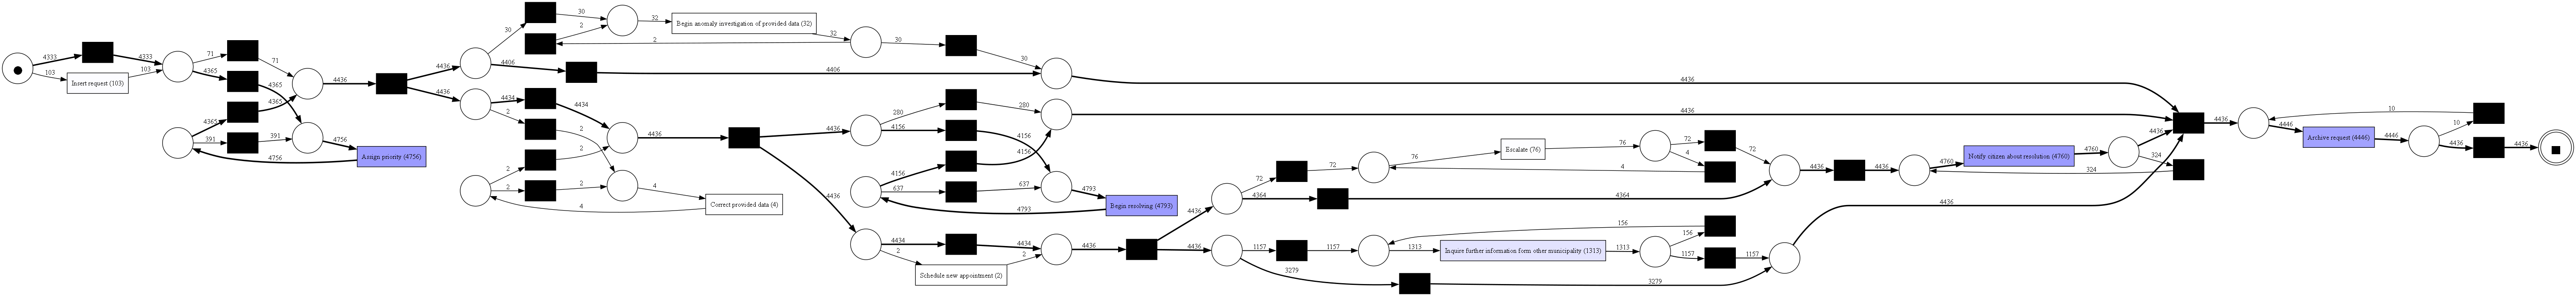

In [11]:
# YOUR CODE HERE
print('The start activities are:')
display(pm4py.get_start_activities(log_archived_frequent))
print('The end activities are:')
display(pm4py.get_end_activities(log_archived_frequent))
net, im, fm = pm4py.discover_petri_net_inductive(log_archived_frequent)

from pm4py.visualization.petri_net import visualizer as pn_visualizer
parameters = {pn_visualizer.Variants.FREQUENCY.value.Parameters.FORMAT: "png"}
gviz = pn_visualizer.apply(net, im, fm, parameters=parameters, variant=pn_visualizer.Variants.FREQUENCY, log=log_archived_frequent)
pn_visualizer.view(gviz)

i) How often are citizens informed several times about the resolution of their request?

In [12]:
# YOUR CODE HERE
filtered_log = pm4py.filter_activities_rework(log_archived_frequent, 'Notify citizen about resolution', 2)
notify_repeats = filtered_log.loc[log_archived_frequent['concept:name'] == 'Notify citizen about resolution']
print(pm4py.get_variants_as_tuples(notify_repeats))

{('Notify citizen about resolution', 'Notify citizen about resolution'): 320, ('Notify citizen about resolution', 'Notify citizen about resolution', 'Notify citizen about resolution'): 2}


ii) In how many of these cases do you expect the citizens to receive the exact same letter twice? Explain your answer.
*Hint: Use the filtered log to answer this question*


In [13]:
filtered_log_twice = pm4py.filter_activities_rework(log_archived_frequent, 'Notify citizen about resolution', 2)

grouped_by_citizen = filtered_log_twice.groupby('citizen_no')

for citizen_no, group in grouped_by_citizen:
    print(f"Citizen No: {citizen_no}")
    display(group)

Citizen No: 0052211


,service_type,workgroup,citizen_no,service_level,concept:name,service,responsible_department,time:timestamp,lifecycle:transition,case:concept:name
18311,Service Type 1,Group 1,0052211,Level 1,Assign priority,Service 1,Department 1,2012-05-23 05:56:57+00:00,complete,Case 453
18312,Service Type 1,Group 1,0052211,Level 1,Begin resolving,Service 1,Department 1,2012-05-23 05:57:05+00:00,complete,Case 453
18313,Service Type 1,Group 1,0052211,Level 1,Notify citizen about resolution,Service 1,Department 1,2012-05-25 10:31:15+00:00,complete,Case 453
18314,Service Type 1,Group 1,0052211,Level 1,Notify citizen about resolution,Service 1,Department 1,2012-05-25 10:31:15+00:00,complete,Case 453
18315,Service Type 1,Group 1,0052211,Level 1,Archive request,Service 1,Department 1,2012-06-27 06:01:06+00:00,complete,Case 453


Citizen No: 005221100


,service_type,workgroup,citizen_no,service_level,concept:name,service,responsible_department,time:timestamp,lifecycle:transition,case:concept:name
4492,Service Type 2,Group 1,005221100,Level 2,Assign priority,Service 3,Department 1,2010-06-01 10:56:49+00:00,complete,Case 1851
4493,Service Type 2,Group 1,005221100,Level 2,Begin resolving,Service 3,Department 1,2010-06-01 14:14:25+00:00,complete,Case 1851
4494,Service Type 2,Group 1,005221100,Level 2,Notify citizen about resolution,Service 3,Department 1,2010-06-01 14:14:39+00:00,complete,Case 1851
4495,Service Type 2,Group 1,005221100,Level 2,Notify citizen about resolution,Service 3,Department 1,2010-06-01 14:14:40+00:00,complete,Case 1851
4496,Service Type 2,Group 1,005221100,Level 2,Archive request,Service 3,Department 1,2010-07-16 11:00:44+00:00,complete,Case 1851
6239,Service Type 1,Group 2,005221100,Level 2,Begin resolving,Service 1,Department 1,2011-11-11 09:10:51+00:00,complete,Case 219
6240,Service Type 1,Group 2,005221100,Level 2,Inquire further information form other municip...,Service 1,Department 1,2011-11-11 09:52:25+00:00,complete,Case 219
6241,Service Type 1,Group 2,005221100,Level 2,Begin resolving,Service 1,Department 1,2011-11-15 07:46:26+00:00,complete,Case 219
6242,Service Type 1,Group 2,005221100,Level 2,Notify citizen about resolution,Service 1,Department 1,2011-11-15 07:47:32+00:00,complete,Case 219
6243,Service Type 1,Group 2,005221100,Level 2,Notify citizen about resolution,Service 1,Department 1,2011-11-15 07:47:33+00:00,complete,Case 219


Citizen No: 005221102


...

,service_type,workgroup,citizen_no,service_level,concept:name,service,responsible_department,time:timestamp,lifecycle:transition,case:concept:name
3846,Service Type 2,Group 2,00522196,Level 2,Assign priority,Service 3,Department 1,2011-07-11 05:20:27+00:00,complete,Case 1729
3847,Service Type 2,Group 2,00522196,Level 2,Begin resolving,Service 3,Department 1,2011-07-15 07:46:32+00:00,complete,Case 1729
3848,Service Type 2,Group 2,00522196,Level 2,Notify citizen about resolution,Service 3,Department 1,2011-07-15 08:20:24+00:00,complete,Case 1729
3849,Service Type 2,Group 2,00522196,Level 2,Begin resolving,Service 3,Department 1,2011-08-02 05:34:25+00:00,complete,Case 1729
3850,Service Type 2,Group 2,00522196,Level 2,Notify citizen about resolution,Service 3,Department 1,2011-08-05 05:17:52+00:00,complete,Case 1729
3851,Service Type 2,Group 2,00522196,Level 2,Archive request,Service 3,Department 1,2011-08-20 05:18:33+00:00,complete,Case 1729
18289,Service Type 2,Group 2,00522196,Level 2,Assign priority,Service 3,Department 1,2011-01-05 14:46:10+00:00,complete,Case 4525
18290,Service Type 2,Group 2,00522196,Level 2,Begin resolving,Service 3,Department 1,2011-01-13 15:39:32+00:00,complete,Case 4525
18291,Service Type 2,Group 2,00522196,Level 2,Notify citizen about resolution,Service 3,Department 1,2011-01-13 15:43:03+00:00,complete,Case 4525
18292,Service Type 2,Group 2,00522196,Level 2,Notify citizen about resolution,Service 3,Department 1,2011-01-13 15:43:03+00:00,complete,Case 4525


Citizen No: 00522197


,service_type,workgroup,citizen_no,service_level,concept:name,service,responsible_department,time:timestamp,lifecycle:transition,case:concept:name
1951,Service Type 1,Group 1,00522197,Level 2,Assign priority,Service 1,Department 1,2012-11-21 08:56:44+00:00,complete,Case 1371
1952,Service Type 1,Group 1,00522197,Level 2,Inquire further information form other municip...,Service 1,Department 1,2012-11-21 08:57:53+00:00,complete,Case 1371
1953,Service Type 1,Group 1,00522197,Level 2,Notify citizen about resolution,Service 1,Department 1,2012-12-28 10:36:52+00:00,complete,Case 1371
1954,Service Type 1,Group 1,00522197,Level 2,Notify citizen about resolution,Service 1,Department 1,2012-12-28 10:36:52+00:00,complete,Case 1371
1955,Service Type 1,Group 1,00522197,Level 2,Archive request,Service 1,Department 1,2013-01-12 10:37:11+00:00,complete,Case 1371
4718,Service Type 1,Group 1,00522197,Level 2,Assign priority,Service 1,Department 1,2011-02-16 15:53:55+00:00,complete,Case 1897
4719,Service Type 1,Group 1,00522197,Level 2,Begin resolving,Service 1,Department 1,2011-02-17 08:00:13+00:00,complete,Case 1897
4720,Service Type 1,Group 1,00522197,Level 2,Notify citizen about resolution,Service 1,Department 1,2011-02-17 13:18:05+00:00,complete,Case 1897
4721,Service Type 1,Group 1,00522197,Level 2,Begin resolving,Service 1,Department 1,2011-03-01 09:35:03+00:00,complete,Case 1897
4722,Service Type 1,Group 1,00522197,Level 2,Notify citizen about resolution,Service 1,Department 1,2011-03-01 13:25:32+00:00,complete,Case 1897


Citizen No: 00522199


,service_type,workgroup,citizen_no,service_level,concept:name,service,responsible_department,time:timestamp,lifecycle:transition,case:concept:name
9937,Service Type 1,Group 1,00522199,Level 2,Assign priority,Service 1,Department 1,2012-03-30 04:41:55+00:00,complete,Case 2904
9938,Service Type 1,Group 1,00522199,Level 2,Begin resolving,Service 1,Department 1,2012-03-30 04:43:26+00:00,complete,Case 2904
9939,Service Type 1,Group 1,00522199,Level 2,Inquire further information form other municip...,Service 1,Department 1,2012-03-30 04:49:33+00:00,complete,Case 2904
9940,Service Type 1,Group 1,00522199,Level 2,Notify citizen about resolution,Service 1,Department 1,2012-04-16 06:22:20+00:00,complete,Case 2904
9941,Service Type 1,Group 1,00522199,Level 2,Notify citizen about resolution,Service 1,Department 1,2012-04-16 06:22:24+00:00,complete,Case 2904
9942,Service Type 1,Group 1,00522199,Level 2,Archive request,Service 1,Department 1,2012-05-16 06:22:42+00:00,complete,Case 2904


In [14]:
num_same = 0
difference = 30* (10**9)
for id in notify_repeats['citizen_no'].unique():
    b = notify_repeats[notify_repeats['citizen_no'] == id]
    s = b['time:timestamp'].values
    if len(s) == 2:
        if abs(s[0]- s[1]) < difference: 
            num_same += 1
        elif len(s) == 3:
            if abs(s[2]-s[1]) < difference:
                num_same += 1
            elif abs(s[2]-s[0]) < difference:
                num_same += 1
print(num_same)

57


__Student Answer:__ 

(e) Out of the 4760 times that citizens were informed about the  resolution of their request, 324 instances involved citizens being informed twice.

(i) ('Notify citizen about resolution', 'Notify citizen about resolution') indicates the activity 'Notify citizen about resolution' happends twice in the sequence. The frequency of this variant is 320. Additionally ('Notify citizen about resolution', 'Notify citizen about resolution', 'Notify citizen about resolution') indicates a trace variant where the activity 'Notify citizen about resolution' occurs three times. There are 2+2 = 4 instances where citizens are informed three times about the resolution of their request.

(ii) If we want to identify cases where citizens received the 'exact same letter' twice, we first need to establish what we mean by 'exact same'. After checking the timestamps for each citizen who received two or more letters, I consider receiving two letters within 30-second to be receiving the exact same two letters. Thus, there are a total of 57 cases where citizens received the exact same two letters.

#### g)
Assess how well this model represents all traces in the log. Compute the token-based replay fitness on the event log `sa_log`. 
Store the log's fitness in a variable called `log_fitness` and display the value.

In [15]:
# YOUR CODE HERE
log_fitness = pm4py.conformance.fitness_token_based_replay(log=sa_log, petri_net=net, initial_marking=im, final_marking=fm)
log_fitness

replaying log with TBR, completed variants ::   0%|          | 0/226 [00:00<?, ?it/s]

{'perc_fit_traces': 99.30131004366812,
 'average_trace_fitness': 0.9992815684836047,
 'log_fitness': 0.9993945290966546,
 'percentage_of_fitting_traces': 99.30131004366812}

#### h)
Before being contempt with the achieved fitness, you want to consider how the fitness is distributed over the individual traces.

i. Create a histogram of the token-based replay fitness given the individual diagnostics of all traces and use the provided `bins`.
Save the diagnostics of the replay in a variable called `replayed_traces`.

replaying log with TBR, completed variants ::   0%|          | 0/226 [00:00<?, ?it/s]

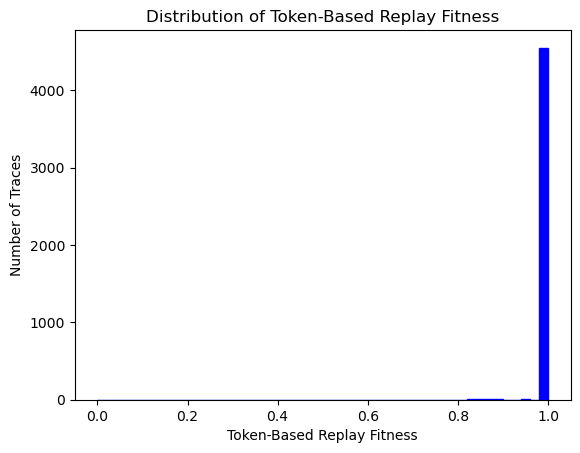

In [16]:
bins = np.arange(0, 1.02, 0.02)

# YOUR CODE HERE
token_replay_result =  pm4py.conformance_diagnostics_token_based_replay(log=sa_log, petri_net=net, initial_marking=im, final_marking=fm)
#display(token_replay_result[0])

replayed_traces = [result['trace_fitness'] for result in token_replay_result]

plt.hist(replayed_traces, bins=bins, color = 'blue', edgecolor='blue')
plt.xlabel('Token-Based Replay Fitness')
plt.ylabel('Number of Traces')
plt.title('Distribution of Token-Based Replay Fitness')
plt.show()

ii. How high is the percentage of traces with full fitness? Save you answer in a variable called `percentage_traces_full_fitness`.

In [17]:
# YOUR CODE HERE
token_replay_result = pm4py.conformance_diagnostics_token_based_replay(log=sa_log, petri_net=net, initial_marking=im, final_marking=fm)
traces_with_full_fitness = sum(result['trace_is_fit'] for result in token_replay_result)

total_traces = len(token_replay_result)
percentage_traces_full_fitness = (traces_with_full_fitness / total_traces) * 100

print("Percentage of traces with full fitness:", percentage_traces_full_fitness)

replaying log with TBR, completed variants ::   0%|          | 0/226 [00:00<?, ?it/s]

Percentage of traces with full fitness: 99.30131004366812


#### i) (4 points) 
Processing speed is always an issue for municipalities. 
Compute the average throughput time in days of all variants in "log_archived_frequent" in a dictionary called `average_throughput`.
Each entry uses the variant as key and the average throughput time as value. 
Which trace variant is the fastest (store the entry describing this variant in a variable called `fastest_variant`)? 
Respectively, which is the slowest (store its entry in `slowest_variant`)?

In [18]:
# YOUR CODE HERE
all_case_durations = pm4py.get_all_case_durations(log_archived_frequent)
average_case_duration = np.mean(all_case_durations)
average_case_duration_days = np.mean(all_case_durations) / (24 * 60 * 60) 
display(f"The average duration of a case in the log is: {average_case_duration_days} day(s).")

'The average duration of a case in the log is: 40.762517215000166 day(s).'

In [19]:
log_archived_frequent[:20]

,service_type,workgroup,citizen_no,service_level,concept:name,service,responsible_department,time:timestamp,lifecycle:transition,case:concept:name
0,Service Type 1,Group 1,0052211,Level 1,Assign priority,Service 1,Department 1,2012-10-09 12:50:17+00:00,complete,Case 1
1,Service Type 1,Group 1,0052211,Level 1,Begin resolving,Service 1,Department 1,2012-10-09 12:51:01+00:00,complete,Case 1
2,Service Type 1,Group 1,0052211,Level 2,Begin resolving,Service 1,Department 1,2012-10-12 13:02:56+00:00,complete,Case 1
3,Service Type 1,Group 1,0052211,Level 2,Notify citizen about resolution,Service 1,Department 1,2012-10-25 09:54:26+00:00,complete,Case 1
4,Service Type 1,Group 1,0052211,Level 2,Archive request,Service 1,Department 1,2012-11-09 11:54:39+00:00,complete,Case 1
5,Service Type 1,Group 3,00522110,Level 3,Assign priority,Service 3,Department 2,2010-02-10 07:50:20+00:00,complete,Case 10
6,Service Type 1,Group 3,00522110,Level 3,Begin resolving,Service 3,Department 2,2010-03-19 07:47:06+00:00,complete,Case 10
7,Service Type 1,Group 3,00522110,Level 3,Notify citizen about resolution,Service 3,Department 2,2010-03-19 07:47:13+00:00,complete,Case 10
8,Service Type 1,Group 3,00522110,Level 3,Archive request,Service 3,Department 2,2010-04-03 05:47:38+00:00,complete,Case 10
9,Service Type 1,Group 1,00522144,Level 2,Assign priority,Service 1,Department 1,2013-04-12 08:25:17+00:00,complete,Case 100


In [20]:
#compute each one case's duration(a process of one citizen, for example case 1)
variants = pm4py.get_variants(log_archived_frequent)
average_throughput = {}

for variant in variants:
    variant_log = pm4py.filter_variants(log_archived_frequent, [variant])
    case_durations = pm4py.get_all_case_durations(variant_log)
    average_throughput[variant] = np.mean(case_durations)

fastest_variant = min(average_throughput, key=average_throughput.get)
slowest_variant = max(average_throughput, key=average_throughput.get)

display(f"Fastest Variant: {fastest_variant}, Throughput Time: {average_throughput[fastest_variant]/ (24 * 60 * 60)} days")
display(f"Slowest Variant: {slowest_variant}, Throughput Time: {average_throughput[slowest_variant]/ (24 * 60 * 60)} days")

"Fastest Variant: ('Assign priority', 'Begin resolving', 'Inquire further information form other municipality', 'Notify citizen about resolution', 'Begin resolving', 'Notify citizen about resolution', 'Archive request'), Throughput Time: 31.52072337962963 days"

"Slowest Variant: ('Assign priority', 'Assign priority', 'Begin resolving', 'Inquire further information form other municipality', 'Begin resolving', 'Inquire further information form other municipality', 'Notify citizen about resolution', 'Archive request'), Throughput Time: 54.60805169753087 days"